# SVM — From Scratch (NumPy only)

**Read `README.md` first.** Every block cites the section (§) it implements.

The training loop is lesson 01's, verbatim — fourth loss of the course (MSE → cross-entropy → hinge). What's new is the OBSESSION: not any separating line, the widest street (README §2.1).

In [1]:
# Block 1 — Imports.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(55)

## Block 2 — Look at the data BEFORE modeling *(README §1)*

Machine QC: temperature + vibration → pass/fail. Belief check: is there a visible street between the classes? (Mostly yes — with a few overlapping machines, which is exactly why the SOFT margin exists.) Note the boundary runs diagonally: lesson 06's forest would staircase this; a tilted street is SVM's native move.

   temperature_c  vibration_mm_s label
0          231.3            7.15  fail
1          188.4            3.42  pass
2          219.3            7.41  fail
3          186.9            6.63  fail
4          239.4            5.03  fail 

200 machines | {'fail': 100, 'pass': 100}


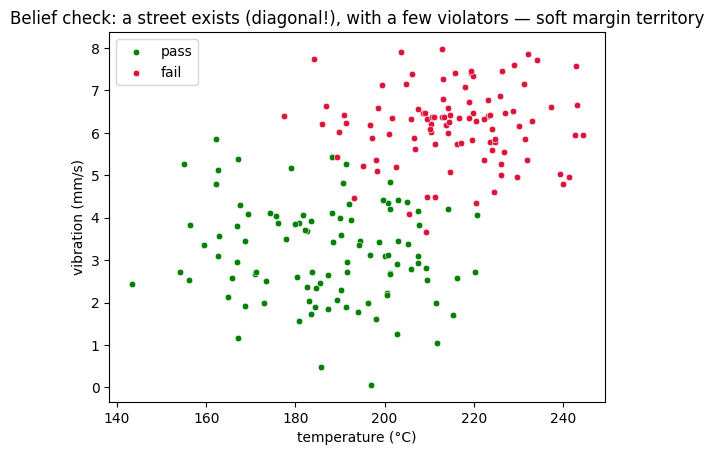

In [2]:
df = pd.read_csv("data/qc_data.csv")
print(df.head(), f"\n\n{len(df)} machines | {df.label.value_counts().to_dict()}")

X = df[["temperature_c", "vibration_mm_s"]].values
labels = df.label.values

plt.scatter(X[labels=="pass",0], X[labels=="pass",1], c="green", s=22, label="pass", edgecolor="white", lw=0.4)
plt.scatter(X[labels=="fail",0], X[labels=="fail",1], c="crimson", s=22, label="fail", edgecolor="white", lw=0.4)
plt.xlabel("temperature (°C)"); plt.ylabel("vibration (mm/s)"); plt.legend()
plt.title("Belief check: a street exists (diagonal!), with a few violators — soft margin territory")
plt.show()

## Block 3 — Scale (mandatory) and relabel to ±1 *(README §0, §4)*

Scaling: margins are DISTANCE math — unscaled temperature (150–250) would drown vibration (0–10); lesson 03's blind ruler, back with a vengeance.

±1 labels: with y ∈ {−1, +1}, the product m = y·(w·x+b) becomes ONE number meaning "correctness": positive = right side, magnitude = how far. Every formula below reads through m.

In [3]:
idx = np.random.permutation(len(df)); cut = int(0.8 * len(df))
tr, te = idx[:cut], idx[cut:]

y = np.where(labels == "fail", 1, -1)                     # README §0: the ±1 convention
mu, sd = X[tr].mean(0), X[tr].std(0)                      # train-only stats — lesson 03 §9's sealed exam
Xs = (X - mu) / sd
Xtr, Xte, ytr, yte = Xs[tr], Xs[te], y[tr], y[te]
print(f"train {len(tr)} / test {len(te)} | labels now in {{-1,+1}}")

train 160 / test 40 | labels now in {-1,+1}


## Block 4 — The hinge loss *(README §3.2)*

max(0, 1 − m): zero beyond the street, linear pain inside it or on the wrong side — plus λ‖w‖², the perpetual pull toward a WIDER street (width = 2/‖w‖, README §3.1).

In [4]:
def svm_loss(Xs, y, w, b, lam):
    """README §3.2 — hinge (stay out of the street) + lambda*||w||^2 (keep it wide)."""
    m = y * (Xs @ w + b)                       # margin score per point
    return np.mean(np.maximum(0, 1 - m)) + lam * np.dot(w, w)

w0, b0 = np.zeros(2), 0.0
print(f"Loss before any learning: {svm_loss(Xtr, ytr, w0, b0, lam=0.01):.3f}")
print("(w=0 puts EVERY point exactly on the boundary: hinge charges 1 per point -> loss = 1)")

Loss before any learning: 1.000
(w=0 puts EVERY point exactly on the boundary: hinge charges 1 per point -> loss = 1)


## Block 5 — The (sub)gradient *(README §3.3)*

The hinge has a corner at m = 1; the subgradient rule: points CLEAR of the street contribute nothing, street-violators each push the boundary away from themselves, and 2λw always shrinks the weights. The gradient itself is a support-vector detector.

In [5]:
def gradients(Xs, y, w, b, lam):
    """README §3.3 — only street-violators (m < 1) get a vote; lambda widens."""
    m = y * (Xs @ w + b)
    viol = m < 1                                          # inside the street or wrong side
    dw = 2 * lam * w - (y[viol, None] * Xs[viol]).sum(axis=0) / len(y)
    db = -y[viol].sum() / len(y)
    return dw, db, viol

_, _, viol0 = gradients(Xtr, ytr, w0, b0, 0.01)
print(f"With w=0, violators: {viol0.sum()}/{len(ytr)} (everyone). Watch this number collapse during training.")

With w=0, violators: 160/160 (everyone). Watch this number collapse during training.


## Block 6 — The training loop: lesson 01, fourth loss *(README §3.3)*

predict → measure → gradient → nudge. If you did lesson 01, you already know this code.

epoch   0 | loss 0.942 | street violators: 160 | width 2/||w|| = 37.21
epoch 200 | loss 0.141 | street violators:  30 | width 2/||w|| = 1.25


epoch 400 | loss 0.140 | street violators:  29 | width 2/||w|| = 1.19
epoch 600 | loss 0.139 | street violators:  29 | width 2/||w|| = 1.13
epoch 799 | loss 0.139 | street violators:  29 | width 2/||w|| = 1.09


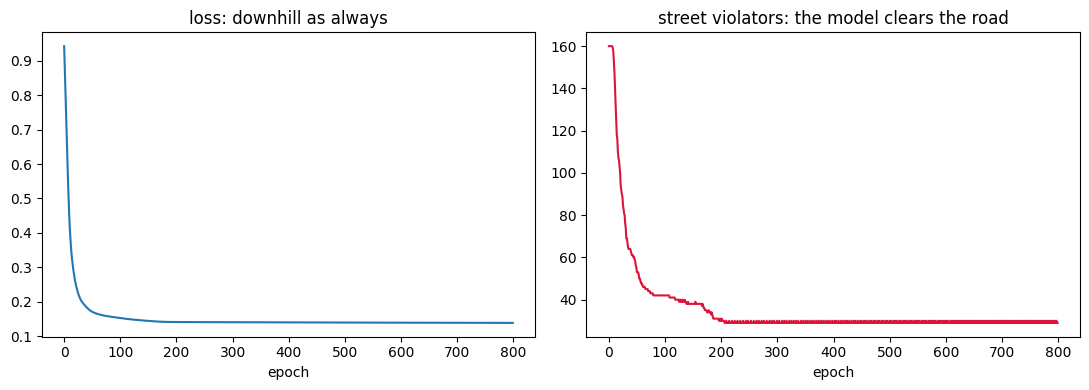

In [6]:
w, b = np.zeros(2), 0.0
lam, lr, epochs = 0.01, 0.05, 800
hist_loss, hist_viol = [], []
for epoch in range(epochs):
    dw, db, viol = gradients(Xtr, ytr, w, b, lam)
    w -= lr * dw
    b -= lr * db
    hist_loss.append(svm_loss(Xtr, ytr, w, b, lam))
    hist_viol.append(viol.sum())
    if epoch % 200 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:3d} | loss {hist_loss[-1]:.3f} | street violators: {hist_viol[-1]:3d} | width 2/||w|| = {2/np.linalg.norm(w):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_loss); axes[0].set_title("loss: downhill as always"); axes[0].set_xlabel("epoch")
axes[1].plot(hist_viol, color="crimson"); axes[1].set_title("street violators: the model clears the road")
axes[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

## Block 7 — The street, its support vectors, and the deletion test *(README §2.1–2.2)*

Draw the learned street; circle the support vectors (m ≤ 1, the gradient's violators at convergence — plus street-touchers). Then the punchline experiment: DELETE all interior points, retrain, and watch the street not care.

support vectors: 30 of 160 training machines — the load-bearing few (README §2.2)


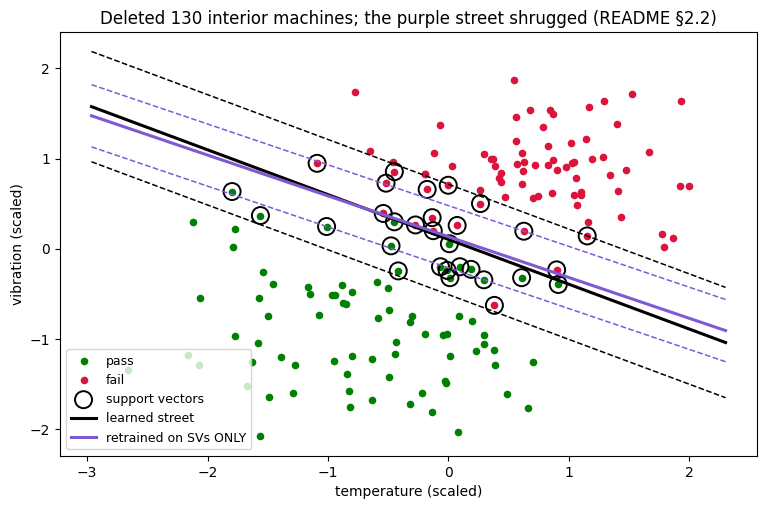

Test accuracy: 90%


In [7]:
def draw_street(w, b, color="black", label=None):
    xs = np.linspace(Xs[:,0].min()-0.3, Xs[:,0].max()+0.3, 50)
    for off, ls, lw in [(0, "-", 2.2), (1, "--", 1.1), (-1, "--", 1.1)]:
        ys = (off - b - w[0]*xs) / w[1]
        plt.plot(xs, ys, ls, color=color, lw=lw,
                 label=(label if off == 0 else None))

m = ytr * (Xtr @ w + b)
sv = m <= 1.02                                            # support vectors: touching or violating
print(f"support vectors: {sv.sum()} of {len(ytr)} training machines — the load-bearing few (README §2.2)")

plt.figure(figsize=(9, 5.5))
plt.scatter(Xtr[ytr==-1,0], Xtr[ytr==-1,1], c="green", s=20, label="pass")
plt.scatter(Xtr[ytr==1,0],  Xtr[ytr==1,1],  c="crimson", s=20, label="fail")
plt.scatter(Xtr[sv,0], Xtr[sv,1], s=150, facecolors="none", edgecolors="black", lw=1.4, label="support vectors")
draw_street(w, b, label="learned street")

# The deletion test: retrain WITHOUT the interior (non-SV) points
w2, b2 = np.zeros(2), 0.0
for _ in range(epochs):
    dw, db, _ = gradients(Xtr[sv], ytr[sv], w2, b2, lam)
    w2 -= lr * dw; b2 -= lr * db
draw_street(w2, b2, color="#805ad5", label="retrained on SVs ONLY")
plt.xlabel("temperature (scaled)"); plt.ylabel("vibration (scaled)"); plt.legend(fontsize=9)
plt.title(f"Deleted {int((~sv).sum())} interior machines; the purple street shrugged (README §2.2)")
plt.show()

pred_te = np.sign(Xte @ w + b)
print(f"Test accuracy: {(pred_te == yte).mean():.0%}")

## Block 8 — The C knob (as λ), swept *(README §4)*

Small λ = huge C: appease every point, narrow contorted street. Large λ = small C: wide tolerant street. The U-curve returns — sweep and let the TEST set pick (lesson 03's rule).

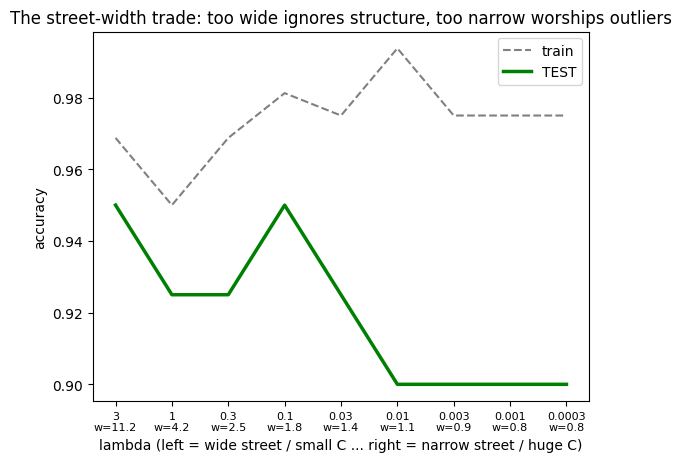

In [8]:
lams = [3, 1, 0.3, 0.1, 0.03, 0.01, 0.003, 0.001, 0.0003]
tr_acc, te_acc, widths = [], [], []
for L in lams:
    wl, bl = np.zeros(2), 0.0
    for _ in range(800):
        dw, db, _ = gradients(Xtr, ytr, wl, bl, L)
        wl -= lr * dw; bl -= lr * db
    tr_acc.append((np.sign(Xtr @ wl + bl) == ytr).mean())
    te_acc.append((np.sign(Xte @ wl + bl) == yte).mean())
    widths.append(2 / np.linalg.norm(wl))

xs = range(len(lams))
plt.plot(xs, tr_acc, "--", color="gray", label="train")
plt.plot(xs, te_acc, color="green", lw=2.5, label="TEST")
plt.xticks(list(xs), [f"{L}\nw={wd:.1f}" for L, wd in zip(lams, widths)], fontsize=8)
plt.xlabel("lambda (left = wide street / small C ... right = narrow street / huge C)")
plt.ylabel("accuracy"); plt.legend()
plt.title("The street-width trade: too wide ignores structure, too narrow worships outliers")
plt.show()

## Block 9 — The kernel moment, by hand *(README §2.4 + §3.4)*

Circle-in-a-ring data: our linear SVM plateaus at ~70% — it can slice off part of the ring, but no street through 2D space can ever *solve* this shape. Now manufacture ONE new coordinate, x3 = x1² + x2², and run the SAME linear SVM in 3D. This hand-made lift IS the kernel idea; real kernels just do it implicitly (and infinitely).

In [9]:
rs = np.random.default_rng(8)
r_in = rs.uniform(0, 1.1, 120); a_in = rs.uniform(0, 2*np.pi, 120)
r_out = rs.uniform(1.7, 2.6, 120); a_out = rs.uniform(0, 2*np.pi, 120)
Xc = np.vstack([np.c_[r_in*np.cos(a_in), r_in*np.sin(a_in)],
                np.c_[r_out*np.cos(a_out), r_out*np.sin(a_out)]])
yc = np.array([1]*120 + [-1]*120)

def fit_linear_svm(Xa, ya, lam=0.01, lr=0.05, epochs=800):
    ww, bb = np.zeros(Xa.shape[1]), 0.0
    for _ in range(epochs):
        mm = ya * (Xa @ ww + bb)
        vv = mm < 1
        ww -= lr * (2*lam*ww - (ya[vv, None] * Xa[vv]).sum(0) / len(ya))
        bb -= lr * (-ya[vv].sum() / len(ya))
    return ww, bb

# 2D: doomed
Xc_s = (Xc - Xc.mean(0)) / Xc.std(0)
w2d, b2d = fit_linear_svm(Xc_s, yc)
acc2d = (np.sign(Xc_s @ w2d + b2d) == yc).mean()

# 3D: lift with x3 = x1^2 + x2^2, then the SAME algorithm
lift = np.c_[Xc, Xc[:,0]**2 + Xc[:,1]**2]
lift_s = (lift - lift.mean(0)) / lift.std(0)
w3d, b3d = fit_linear_svm(lift_s, yc)
acc3d = (np.sign(lift_s @ w3d + b3d) == yc).mean()

print(f"linear SVM in 2D : {acc2d:.0%}   <- no street exists in this space")
print(f"same SVM, lifted : {acc3d:.0%}   <- ONE manufactured coordinate, and the street trick works again")
print()
print("That is the kernel idea (README §2.4). Real kernels (RBF etc.) perform lifts like this")
print("implicitly — even infinite-dimensional ones — by only ever computing pairwise")
print("similarities. The library notebook shows the industrial version.")

linear SVM in 2D : 70%   <- no street exists in this space
same SVM, lifted : 100%   <- ONE manufactured coordinate, and the street trick works again

That is the kernel idea (README §2.4). Real kernels (RBF etc.) perform lifts like this
implicitly — even infinite-dimensional ones — by only ever computing pairwise
similarities. The library notebook shows the industrial version.


## Block 10 — Where does it fail? *(README §5 + §6)*

The misread machines, and the health meter: our support-vector count was ~1/4 of the data — a real street exists. When SVs ≈ everyone, no street exists and the SVM is the wrong tool.

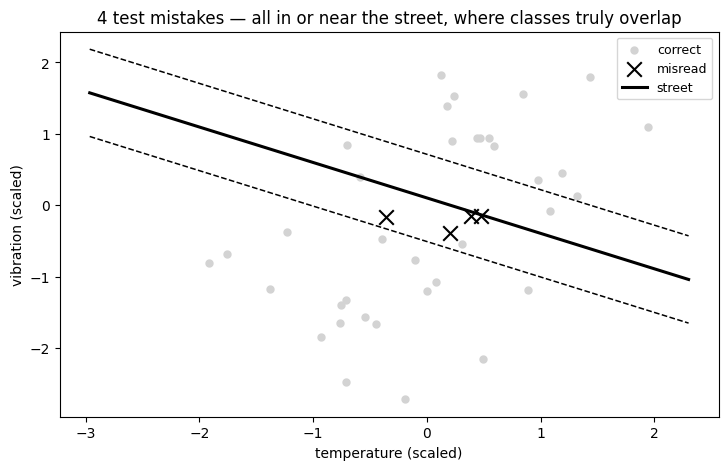

Health meter (README §5): 30/160 support vectors (~19%).
Clean margin. If this were ~90%, the honest conclusion would be: no street exists — change tools.


In [10]:
wrong = np.sign(Xte @ w + b) != yte
plt.figure(figsize=(8.5, 5))
plt.scatter(Xte[~wrong,0], Xte[~wrong,1], c="lightgray", s=25, label="correct")
plt.scatter(Xte[wrong,0], Xte[wrong,1], c="black", marker="x", s=110, label="misread")
draw_street(w, b, label="street")
plt.xlabel("temperature (scaled)"); plt.ylabel("vibration (scaled)"); plt.legend(fontsize=9)
plt.title(f"{int(wrong.sum())} test mistakes — all in or near the street, where classes truly overlap")
plt.show()

print(f"Health meter (README §5): {sv.sum()}/{len(ytr)} support vectors (~{sv.mean():.0%}).")
print("Clean margin. If this were ~90%, the honest conclusion would be: no street exists — change tools.")

---
## What you now own

- The max-margin philosophy: among all correct boundaries, the widest street generalizes best
- The hinge loss and its flat zero — why only the borderline points (support vectors) shape the model
- The same lesson 01 training loop, now with its fourth loss — and a gradient that doubles as an SV detector
- The C/λ trade (width vs violations), the SV-count health meter, and the mandatory return of scaling
- The kernel idea, performed by hand: lift the data until a flat cut works

**Next:** `svm_with_library.ipynb` for sklearn's SVC (and the real RBF kernel) — then folder `08-gradient-boosting`: the anti-forest, attacking bias instead of variance.